## Validação Completa com ModelSentry
Este notebook realiza a validação completa do modelo de fraude (escorado no notebook 02), executando a ValidationSuite com múltiplos KRIs, visualizando os resultados e gerando o relatório HTML final.

In [1]:
import pandas as pd
import sqlite3
import sys
import os
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))

from modelsentry.core.suite import ValidationSuite
from modelsentry.dimensions.quantitative.stability import PSI_KRI
from modelsentry.dimensions.quantitative.performance import AUCROC_KRI, KolmogorovSmirnovKRI
from modelsentry.dimensions.quantitative.methodology import VIF_KRI
from modelsentry.dimensions.qualitative.data_quality import MissingValuesKRI
from modelsentry.io.writer import save_summary_to_sqlite, save_artifacts_to_sqlite
from modelsentry.viz.plots import plot_kri_summary, plot_psi_mensal
from modelsentry.reporting.generator import generate_html_report

%matplotlib inline

# Conectar ao banco de dados com as predições reais do modelo de fraude
conn = sqlite3.connect('../data/simulacao.db')
df = pd.read_sql('SELECT * FROM tb_dados_escorados', conn)
conn.close()

# Quantidade de registros por safra
display(df.groupby(['data_ref', 'amostra']).size().reset_index(name='qtd'))

,data_ref,amostra,qtd
0,2022-01-01,dev,300
1,2022-02-01,dev,300
2,2022-03-01,dev,300
3,2022-04-01,dev,300
4,2022-05-01,dev,300
5,2022-06-01,dev,300
6,2022-07-01,dev,300
7,2022-08-01,dev,300
8,2022-09-01,dev,300
9,2022-10-01,dev,300


## 2. Configurando a ValidationSuite
Vamos adicionar os testes configurados para a nossa validação.

In [2]:
features = [col for col in df.columns if col.startswith('var_')]

suite = ValidationSuite(
    df=df,
    date_col='data_ref',
    sample_col='amostra',
    target_col='target',
    score_col='score',
    features=features
)

suite.add_test(MissingValuesKRI(fail_threshold=0.15))
suite.add_test(KolmogorovSmirnovKRI(min_passed=0.4))
suite.add_test(PSI_KRI(ref_sample='dev', eval_samples=['oot']))
suite.add_test(VIF_KRI(max_vif=5.0))

# Executando todos os testes
resultados = suite.run()

global_risk = suite.calculate_global_risk(resultados)
print(f"🌍 Risco Global Hierárquico: {global_risk:.2f}\n")

for r in resultados:
    print(f"📝 Teste: {r.name}")
    print(f"   Valor Base: {r.value:.3f}")
    print(f"   Risk Score (0 a 100): {r.risk_score}")
    print(f"   Nível de Risco: {r.risk_level}\n")

🌍 Risco Global Hierárquico: 26.22

📝 Teste: Missing Values KRI
   Valor Base: 0.020
   Risk Score (0 a 100): 16.0
   Nível de Risco: Muito Baixo

📝 Teste: Kolmogorov-Smirnov (KS) KRI
   Valor Base: 0.450
   Risk Score (0 a 100): 60.0
   Nível de Risco: Médio

📝 Teste: Population Stability Index (PSI) KRI
   Valor Base: 2.815
   Risk Score (0 a 100): 0.0
   Nível de Risco: Muito Baixo

📝 Teste: Variance Inflation Factor (VIF) KRI
   Valor Base: 3.200
   Risk Score (0 a 100): 49.33
   Nível de Risco: Médio



## 3. Visualizações
Gerando o resumo de KRIs e o gráfico do PSI.

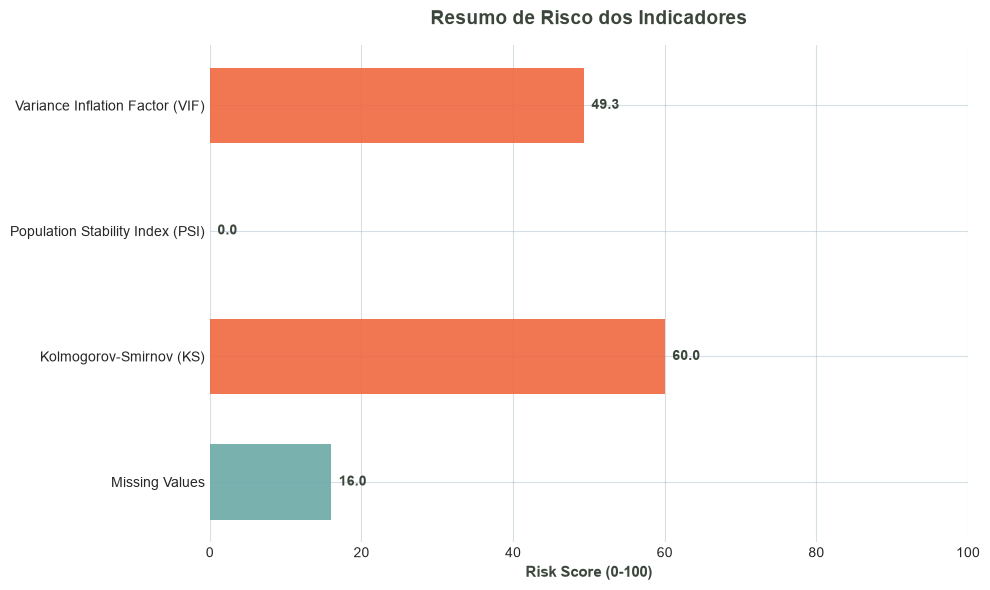

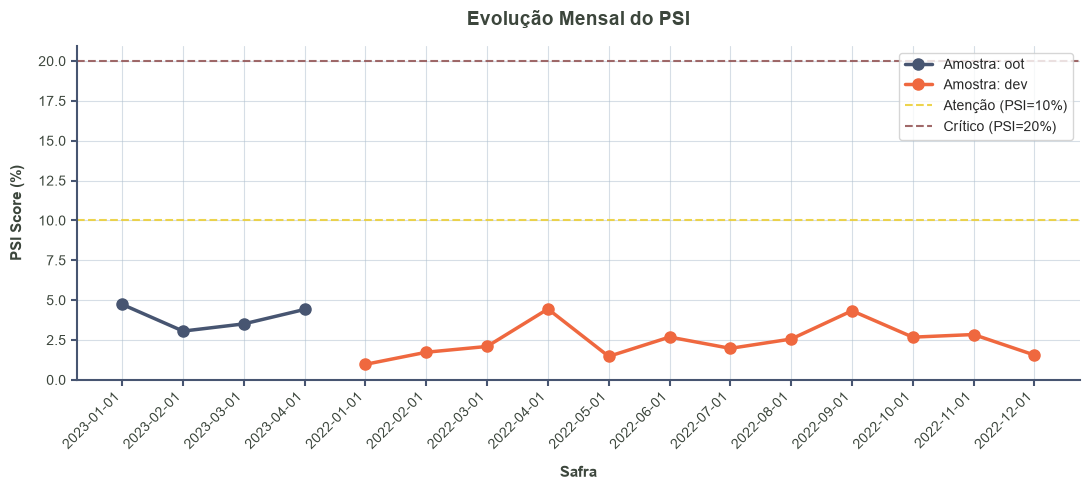

In [3]:
# Resumo Geral dos KRIs
fig_summary = plot_kri_summary(resultados)
plt.show()

# Gráfico de PSI
for r in resultados:
    if r.name == "Population Stability Index (PSI) KRI":
        fig_psi = plot_psi_mensal(r)
        plt.show()

## 4. Salvando Resultados e Gerando Relatório HTML
Por fim, vamos persistir os resultados no SQLite e gerar o relatório HTML executivo com as novas cores.

In [4]:
DB_PATH = "../data/resultados_modelsentry.db"

# Salvar no SQLite
save_summary_to_sqlite(resultados, DB_PATH)
save_artifacts_to_sqlite(resultados, DB_PATH)
print(f"✅ Resultados salvos no banco SQLite: {DB_PATH}")

# Gerar o Relatório HTML
html_path = generate_html_report(suite, resultados, global_risk, "../data/relatorio_final.html")
print(f"📄 Relatório HTML gerado com sucesso em: {html_path}")

✅ Resultados salvos no banco SQLite: ../data/resultados_modelsentry.db
📄 Relatório HTML gerado com sucesso em: ../data/relatorio_final.html
